# Retinotopography: HD Class 3, RF peak angle, and shank depth

Four requested RF sessions are paired with the **existing free-moving HD sources in `tc_comparison_pairs.ipynb`**. Unit identity is always mouse + date + probe + unit ID; session numbers are recorded separately.

| Mouse | RF session | HD tuning-curve session | Probe |
|---|---|---|---|
| m14 | 260609_3 | 260609_1 | A |
| m15 | 260630_3 | 260630_1 | A + B |
| m19 | 260827_2 | 260827_9 | A |
| m20 | 260921_2 | 260921_9 | A |

Run this notebook on **hhw9l84** with `~/.virtualenvs/rfmapping`, from `~/Developer/rfmapping`. It reads source recordings and writes only this analysis's outputs. Existing Class 3 classification is reused through `load_hd_profiles`; no classification is implemented here.

In [1]:
%matplotlib inline
from pathlib import Path
import hashlib
import json
import sys

import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib import pyplot as plt
from scipy.stats import linregress
from probeinterface import read_openephys

from Utils.direction_comparison import load_hd_profiles, peak_angles
from Utils.plotting import LIGHT_PLOT_STYLE
from Utils.rfmap import load_rf_maps
from Utils.si_utils import WaveformArtifactStore

plt.rcParams.update(LIGHT_PLOT_STYLE)
root = Path("/mnt/senzailab/Kai/#Recording")
output_dir = Path("output/retinotopography")
output_dir.mkdir(parents=True, exist_ok=True)

recordings = [
    dict(mouse="m14", date="260609", rf_session=3, hd_session=1, position_session=3, probe="A"),
    dict(mouse="m15", date="260630", rf_session=3, hd_session=1, position_session=3, probe="A"),
    dict(mouse="m15", date="260630", rf_session=3, hd_session=1, position_session=3, probe="B"),
    dict(mouse="m19", date="260827", rf_session=2, hd_session=9, position_session=9, probe="A"),
    dict(mouse="m20", date="260921", rf_session=2, hd_session=9, position_session=2, probe="A"),
]
hd_class = 3
response_window_s = (0.0, 0.2)
require_rf_detection = False  # All HD cells with a non-flat measured RF map; optional saved 2-D RF gate.
pd.DataFrame(recordings)

,mouse,date,rf_session,hd_session,position_session,probe
0,m14,260609,3,1,3,A
1,m15,260630,3,1,3,A
2,m15,260630,3,1,3,B
3,m19,260827,2,9,9,A
4,m20,260921,2,9,2,A


## Load all HD cells, then show one overview per requested session

HD preferred direction is the maximum of the **native 180-bin (2°), occupancy-corrected, unsmoothed HD curve**. Ties use the first source bin, matching `peak_angles`. The overview includes every Class 3 HD cell even if its position or RF response is unavailable in the paired RF session. Each heatmap row is independently divided by that unit's maximum firing rate.

In [2]:
hd_profiles = {}
source_rows = []
for recording in recordings:
    mouse, date, probe = (recording[key] for key in ("mouse", "date", "probe"))
    session_dir = root / mouse / date / f"{date}_{recording['rf_session']}"
    data_dir = session_dir / "data"
    position_data_dir = root / mouse / date / f"{date}_{recording['position_session']}" / "data"
    tc_file = (root / mouse / date / f"{date}_{recording['hd_session']}" /
               "data" / "tuning_curves" / f"Probe{probe}" / "tuning_curves.tc")
    rf_file = (data_dir / "rfmapping/good/-100_400_1ms" / f"Probe{probe}" /
               f"regular_unitsSpikeCounts_{date}_{recording['rf_session']}.rfmap")
    key = (mouse, date, probe)
    hd_profiles[key] = load_hd_profiles(tc_file, probe=probe, bins=180,
                                        smoothing_deg=0, hd_class=hd_class)
    source_rows.append({**recording, "hd_file": str(tc_file), "rf_file": str(rf_file),
                       "waveform_dir": str(position_data_dir / "waveform" / f"Probe{probe}"),
                       "position_dir": str(position_data_dir / "spike_position" / f"Probe{probe}"),
                       "settings_file": str(session_dir / date / "Record Node 102/settings.xml"),
                       "hd_count": len(hd_profiles[key])})
sources = pd.DataFrame(source_rows)
sources.to_csv(output_dir / "sources.csv", index=False)
display(sources[["mouse", "date", "rf_session", "hd_session", "position_session", "probe", "hd_count"]])

,mouse,date,rf_session,hd_session,position_session,probe,hd_count
0,m14,260609,3,1,3,A,46
1,m15,260630,3,1,3,A,51
2,m15,260630,3,1,3,B,47
3,m19,260827,2,9,9,A,88
4,m20,260921,2,9,2,A,38


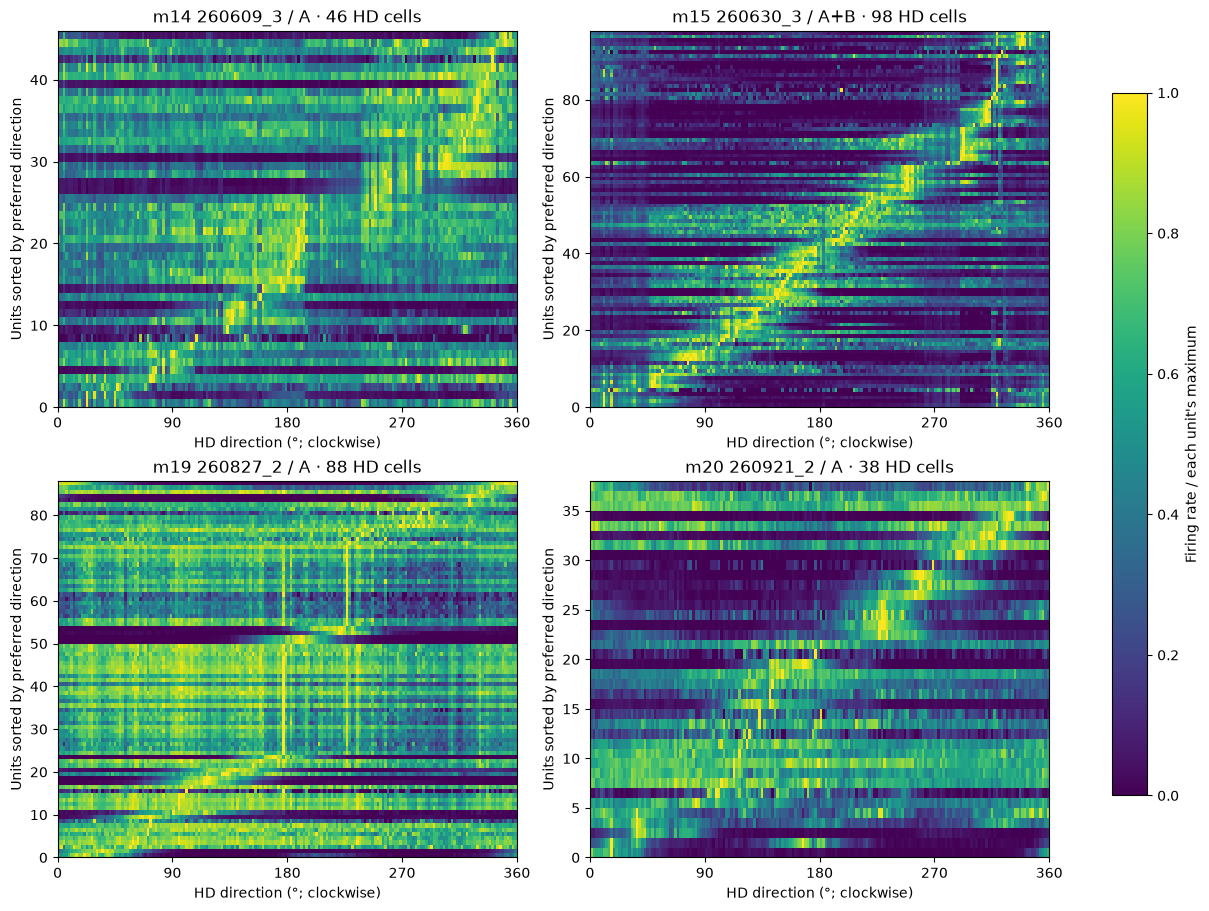

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9), layout="constrained")
for ax, (mouse, session_sources) in zip(axes.flat, sources.groupby("mouse", sort=False), strict=True):
    curves = []
    for source in session_sources.itertuples():
        table = hd_profiles[(source.mouse, source.date, source.probe)]
        table = table.copy()
        table.attrs = {}
        curves.append(table)
    table = pd.concat(curves)
    angles = np.asarray(table.columns) % 360
    preferred = peak_angles(table, table.index) % 360
    values = table.to_numpy()[np.argsort(preferred, kind="stable")]
    values = values / np.nanmax(values, axis=1, keepdims=True)
    image = ax.imshow(values[:, np.argsort(angles)], origin="lower", aspect="auto",
                      interpolation="nearest", extent=(0, 360, 0, len(table)),
                      cmap="viridis", vmin=0, vmax=1)
    source = session_sources.iloc[0]
    probes = "+".join(session_sources.probe)
    ax.set(title=f"{mouse} {source.date}_{source.rf_session} / {probes} · {len(table)} HD cells",
           xlabel="HD direction (°; clockwise)", ylabel="Units sorted by preferred direction",
           xticks=[0, 90, 180, 270, 360])
fig.colorbar(image, ax=axes, label="Firing rate / each unit's maximum", shrink=0.85)
fig.savefig(output_dir / "hd_overview.png", dpi=180, facecolor="white", transparent=False)
plt.show()

## Verify the coordinate direction using each recording's probe geometry

For every probe, `read_openephys(settings.xml)` loads the recorded Neuropixels geometry and physical shank-tip coordinates. We compare all 384 contacts, in acquisition-channel order, to both the waveform export and Kilosort's `channel_positions.npy` / `ops.npy["probe"]["kcoords"]`.

**All five probes are NP2013. The physical tip is at y = −217 µm, below all recorded contacts. Larger y values point toward the top/base (shallower); smaller y values point toward the bottom/tip (deeper).** This is position along the probe, not anatomical distance below the brain surface. The upstream [ProbeInterface geometry implementation](https://github.com/SpikeInterface/probeinterface/blob/main/src/probeinterface/neuropixels_tools.py) also documents the tip at negative y and top at positive y.

Unit positions come from the existing `WaveformArtifactStore` and its referenced `spike_position/Probe*/positions.csv`. m14/m15 use PTP center-of-mass positions (75 µm radius); m19/m20 use the saved canonical concat Kilosort spike-position median. Shank IDs come from each unit's best waveform channel, not from rounding its x coordinate. No waveforms are recomputed.

**m19 position source:** RF2 exports only the units present in that session. We explicitly use the HD9 position/waveform export, which has the same canonical concat source and exactly the same positions for every shared unit; this includes all 88 HD cells when defining each shank origin. The other four probes use their requested RF-session exports. The checks below verify the shared positions and geometry rather than estimating positions for absent units.

In [4]:
geometry_rows = []
position_rows = []
for source in sources.itertuples():
    store = WaveformArtifactStore(source.waveform_dir)
    if source.position_session != source.rf_session:
        rf_store = WaveformArtifactStore(root / source.mouse / source.date /
                                         f"{source.date}_{source.rf_session}" /
                                         "data" / "waveform" / f"Probe{source.probe}")
        assert store.manifest["canonical_source"] == rf_store.manifest["canonical_source"]
        for unit_id in set(store.unit_summaries) & set(rf_store.unit_summaries):
            unit, rf_unit = store.unit_summaries[unit_id], rf_store.unit_summaries[unit_id]
            np.testing.assert_allclose([unit.unit_x_um, unit.unit_y_um],
                                       [rf_unit.unit_x_um, rf_unit.unit_y_um], rtol=0, atol=0)
        np.testing.assert_array_equal(store.channel_locations, rf_store.channel_locations)
        np.testing.assert_array_equal(store.channel_shank_ids, rf_store.channel_shank_ids)
    setup = read_openephys(source.settings_file, stream_name=f"Probe{source.probe}")
    channel_order = np.argsort(setup.device_channel_indices)
    coordinates = setup.contact_positions[channel_order]
    shanks = setup.shank_ids[channel_order].astype(int)
    kilosort_dir = Path(store.manifest["session"]["kilosort_dir"])
    kilosort_coordinates = np.load(kilosort_dir / "channel_positions.npy")
    kilosort_shanks = np.load(kilosort_dir / "ops.npy", allow_pickle=True).item()["probe"]["kcoords"]
    np.testing.assert_allclose(coordinates, store.channel_locations, rtol=0, atol=1e-6)
    np.testing.assert_allclose(coordinates, kilosort_coordinates, rtol=0, atol=1e-6)
    np.testing.assert_array_equal(shanks, store.channel_shank_ids)
    np.testing.assert_array_equal(shanks, np.asarray(kilosort_shanks).astype(int))
    tips = np.asarray(setup.annotations["shank_tips"])
    position_manifest = json.loads((Path(source.position_dir) / "manifest.json").read_text())
    position_method = (position_manifest["spike_position"]["method"]
                       if "spike_position" in position_manifest
                       else position_manifest["canonical_source"]["method"])
    for shank in np.unique(shanks):
        channel_y = coordinates[shanks == shank, 1]
        tip_y = tips[shank, 1]
        assert tip_y < channel_y.min()
        geometry_rows.append(dict(mouse=source.mouse, date=source.date, probe=source.probe,
                                  shank=int(shank), part_number=setup.annotations["part_number"],
                                  min_channel_y_um=channel_y.min(), max_channel_y_um=channel_y.max(),
                                  tip_y_um=tip_y, deeper_is="smaller_y",
                                  max_coordinate_error_um=float(np.max(abs(coordinates - store.channel_locations))),
                                  position_method=position_method))
    for unit_id, unit in store.unit_summaries.items():
        position_rows.append(dict(mouse=source.mouse, date=source.date, probe=source.probe,
                                  unit_id=unit_id, shank=int(store.channel_shank_ids[unit.best_channel_index]),
                                  x_um=unit.unit_x_um, y_um=unit.unit_y_um,
                                  best_channel_id=unit.best_channel_id,
                                  best_channel_y_um=unit.best_channel_y_um))
geometry = pd.DataFrame(geometry_rows)
positions = pd.DataFrame(position_rows)
geometry.to_csv(output_dir / "depth_convention.csv", index=False)
display(geometry.round(3))

,mouse,date,probe,shank,part_number,min_channel_y_um,max_channel_y_um,tip_y_um,deeper_is,max_coordinate_error_um,position_method
0,m14,260609,A,0,NP2013,510.0,1935.0,-217.0,smaller_y,0.0,center_of_mass
1,m14,260609,A,1,NP2013,510.0,1935.0,-217.0,smaller_y,0.0,center_of_mass
2,m14,260609,A,2,NP2013,510.0,1935.0,-217.0,smaller_y,0.0,center_of_mass
3,m14,260609,A,3,NP2013,510.0,1935.0,-217.0,smaller_y,0.0,center_of_mass
4,m15,260630,A,0,NP2013,0.0,1425.0,-217.0,smaller_y,0.0,center_of_mass
5,m15,260630,A,1,NP2013,0.0,1425.0,-217.0,smaller_y,0.0,center_of_mass
6,m15,260630,A,2,NP2013,0.0,1425.0,-217.0,smaller_y,0.0,center_of_mass
7,m15,260630,A,3,NP2013,0.0,1425.0,-217.0,smaller_y,0.0,center_of_mass
8,m15,260630,B,0,NP2013,0.0,1425.0,-217.0,smaller_y,0.0,center_of_mass
9,m15,260630,B,1,NP2013,0.0,1425.0,-217.0,smaller_y,0.0,center_of_mass


## RF maximum bin and eligibility

For each HD cell, take the maximum spatial bin of the **unsmoothed 2-D RF response over [0, 200) ms** after onset, using the RF loader's spatial occupancy normalization. The RF angle is that bin's **horizontal x angle**; its raw stimulus Y coordinate is retained as `rf_max_y_deg` in the results table (not relabeled as up-positive physical elevation). This is a maximum bin, not a fitted RF center or a maximum after collapsing elevations.

We retain the existing RF coordinate convention without negation, rotation, smoothing, or resampling. The saved response metric is summed counts / stimulus occupancy time; it is used only to select a spatial maximum and is not relabeled as a mean post-onset firing rate. Flat/all-zero or wholly unmeasured maps have no preferred RF angle. Ties are counted and resolved by the first native y/x bin. The saved 2-D RF significance mask is reported; `require_rf_detection=False` includes measured peaks from all HD cells, as requested, and does not imply that every peak is a significant RF.

Positions are taken from the explicit sources above, including the verified m19 HD9 canonical positions; any unavailable positions would be reported and excluded. Units absent from the RF session remain in the HD depth analysis and do not enter the RF depth analysis. All Class 3 HD cells with finite positions and preferred directions define the per-shank origin, **before** applying RF eligibility: `normalized_depth_um = y_um − minimum_HD_y_um`. Thus 0 is the deepest eligible HD unit and positive values are µm toward the top of that shank; each shank retains physical distances rather than being rescaled to [0, 1].

In [5]:
unit_rows = []
identity = ["mouse", "date", "probe", "unit_id"]
for source in sources.itertuples():
    table = hd_profiles[(source.mouse, source.date, source.probe)]
    preferred = pd.Series(peak_angles(table, table.index) % 360, index=table.index)
    maps = load_rf_maps(source.rf_file, unit_firing_rate=True).sum(
        *response_window_s, show_progress=False)
    maps_by_id = {rf_map.unit_id: rf_map for rf_map in maps}
    with np.load(Path(source.rf_file).with_suffix(".npz"), allow_pickle=False) as detected:
        detected_ids = set(detected["unit_ids"][np.any(detected["mask_2d"], axis=(1, 2))].tolist())
    for (_, unit_id), hd_angle in preferred.items():
        row = dict(mouse=source.mouse, date=source.date, probe=source.probe, unit_id=int(unit_id),
                   hd_class=hd_class, hd_preferred_deg=hd_angle, rf_max_angle_deg=np.nan,
                   rf_max_y_deg=np.nan, rf_max_response=np.nan, rf_peak_ties=0,
                   rf_detected_2d=unit_id in detected_ids, rf_peak_status="unit_not_in_rf")
        if unit_id in maps_by_id:
            rf_map = maps_by_id[unit_id]
            response = rf_map.to_2d_array()
            finite_values = response[np.isfinite(response)]
            row["rf_peak_status"] = "flat_or_unmeasured"
            if finite_values.size and np.ptp(finite_values) > 0:
                y, x = np.unravel_index(np.nanargmax(response), response.shape)
                row.update(rf_max_angle_deg=float(rf_map.x_positions[x]),
                           rf_max_y_deg=float(rf_map.y_positions[y]),
                           rf_max_response=float(response[y, x]),
                           rf_peak_ties=int(np.sum(response == response[y, x])),
                           rf_peak_status="measured_peak")
        unit_rows.append(row)
units = pd.DataFrame(unit_rows).merge(positions, on=identity, how="left", validate="one_to_one")
units["depth_eligible"] = np.isfinite(units.y_um) & np.isfinite(units.hd_preferred_deg)
units["shank_label"] = [
    f"{m} {d}/{p} S{int(s)}" if pd.notna(s) else None
    for m, d, p, s in units[["mouse", "date", "probe", "shank"]].itertuples(index=False, name=None)
]
hd_depth = units.loc[units.depth_eligible]
origins = hd_depth.groupby("shank_label").y_um.min()
units["deepest_hd_y_um"] = units.shank_label.map(origins)
units["normalized_depth_um"] = units.y_um - units.deepest_hd_y_um
units["rf_depth_eligible"] = units.depth_eligible & units.rf_max_angle_deg.notna()
if require_rf_detection:
    units["rf_depth_eligible"] &= units.rf_detected_2d
hd_depth = units.loc[units.depth_eligible].copy()
rf_depth = units.loc[units.rf_depth_eligible].copy()
np.testing.assert_allclose(hd_depth.groupby("shank_label").normalized_depth_um.min(), 0)
assert (hd_depth.normalized_depth_um >= 0).all()
assert not units.duplicated(identity).any()
units.to_csv(output_dir / "unit_angles_depth.csv", index=False)
summary = units.groupby(["mouse", "date", "probe"], sort=False).agg(
    hd_cells=("unit_id", "size"), hd_with_depth=("depth_eligible", "sum"),
    hd_with_rf_peak_and_depth=("rf_depth_eligible", "sum"),
    saved_significant_rf=("rf_detected_2d", "sum"))
display(summary)
display(units.loc[~units.depth_eligible, identity + ["hd_preferred_deg", "rf_peak_status"]])
shank_summary = hd_depth.groupby("shank_label", sort=True).agg(
    n_hd=("unit_id", "size"), deepest_hd_y_um=("y_um", "min"),
    normalized_span_um=("normalized_depth_um", "max"))
shank_summary["n_rf"] = rf_depth.groupby("shank_label").size().reindex(shank_summary.index, fill_value=0)
shank_summary.to_csv(output_dir / "shank_summary.csv")
display(shank_summary.round(3))

hd_cells  hd_with_depth  hd_with_rf_peak_and_depth  \
mouse date   probe                                                       
m14   260609 A            46             46                         46   
m15   260630 A            51             51                         51   
             B            47             47                         47   
m19   260827 A            88             88                         36   
m20   260921 A            38             38                         38   

                    saved_significant_rf  
mouse date   probe                        
m14   260609 A                        13  
m15   260630 A                        25  
             B                        25  
m19   260827 A                        16  
m20   260921 A                        14

,mouse,date,probe,unit_id,hd_preferred_deg,rf_peak_status


,n_hd,deepest_hd_y_um,normalized_span_um,n_rf
shank_label,,,,
m14 260609/A S0,1,1112.368,0.000,1
m14 260609/A S1,6,1388.010,322.709,6
m14 260609/A S2,27,658.451,998.065,27
m14 260609/A S3,12,529.472,1228.116,12
m15 260630/A S0,16,406.526,783.630,16
m15 260630/A S1,23,156.785,898.055,23
m15 260630/A S2,11,130.265,754.209,11
m15 260630/A S3,1,1229.528,0.000,1
m15 260630/B S0,15,229.909,824.629,15


## One 1×2 depth figure per session

Each requested session has its own figure: **left, normalized depth vs HD preferred direction; right, normalized depth vs RF maximum-bin horizontal angle**. All eligible shanks from that session share each panel, with the same shank colors on both sides. m15 Probe A and B appear together, distinguished by probe + shank. Colored lines are per-shank OLS fits; the dashed black line is the **session's** pooled descriptive fit. Fits require at least 3 units and 2 distinct depths. Unfit shanks remain visible as points; empty shanks are omitted.

The regression CSV contains per-shank and per-session sample size, slope (°/µm), intercept, R², p value, and standard error. There is no all-session pooled fit.

**Angles are circular.** These requested OLS fits use HD in [0, 360) and RF in its native signed coordinate interval, without data-dependent unwrapping. A slope/p value can change when the angular origin is moved; it is descriptive and is not a circular-linear test. Session-pooled p values also treat units as independent and do not account for shank clustering. Inspect the colored within-shank relationships rather than inferring a population effect from the pooled p value alone.


In [6]:
def fit_relationship(data, angle_column, relationship):
    rows = []
    groups = [("pooled", data), *data.groupby("shank_label", sort=True)]
    for label, group in groups:
        row = dict(relationship=relationship, shank=label, n=len(group),
                   slope_deg_per_um=np.nan, intercept_deg=np.nan, r_squared=np.nan,
                   p_value=np.nan, slope_stderr=np.nan, status="insufficient_distinct_depths_or_units")
        if len(group) >= 3 and group.normalized_depth_um.nunique() >= 2:
            result = linregress(group.normalized_depth_um, group[angle_column])
            row.update(slope_deg_per_um=result.slope, intercept_deg=result.intercept,
                       r_squared=result.rvalue**2, p_value=result.pvalue,
                       slope_stderr=result.stderr, status="fit")
        rows.append(row)
    return pd.DataFrame(rows)


def plot_depth(ax, data, angle_column, fits, colors, title, angle_label, ylim):
    by_shank = fits.set_index("shank")
    for label, group in data.groupby("shank_label", sort=True):
        color = colors[label]
        probe_shank = f"{group.probe.iloc[0]} S{int(group.shank.iloc[0])}"
        ax.scatter(group.normalized_depth_um, group[angle_column], s=32, color=color,
                   edgecolor="white", linewidth=0.35, alpha=0.9,
                   label=f"{probe_shank} (n={len(group)})")
        fit = by_shank.loc[label]
        if fit.status == "fit":
            x = np.array([group.normalized_depth_um.min(), group.normalized_depth_um.max()])
            ax.plot(x, fit.intercept_deg + fit.slope_deg_per_um * x, color=color, linewidth=1.1)
    fit = by_shank.loc["pooled"]
    if fit.status == "fit":
        x = np.array([data.normalized_depth_um.min(), data.normalized_depth_um.max()])
        ax.plot(x, fit.intercept_deg + fit.slope_deg_per_um * x, "k--", linewidth=1.8,
                label="Session OLS")
        title += f"\nSession OLS: slope={fit.slope_deg_per_um:.3f}°/µm · R²={fit.r_squared:.3f} · p={fit.p_value:.3g}"
    ax.set(title=title, xlabel="Normalized depth (µm above deepest HD unit)",
           ylabel=angle_label, ylim=ylim)
    ax.grid(alpha=0.45)
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.16), ncol=3, fontsize=9,
              frameon=True, borderaxespad=0)


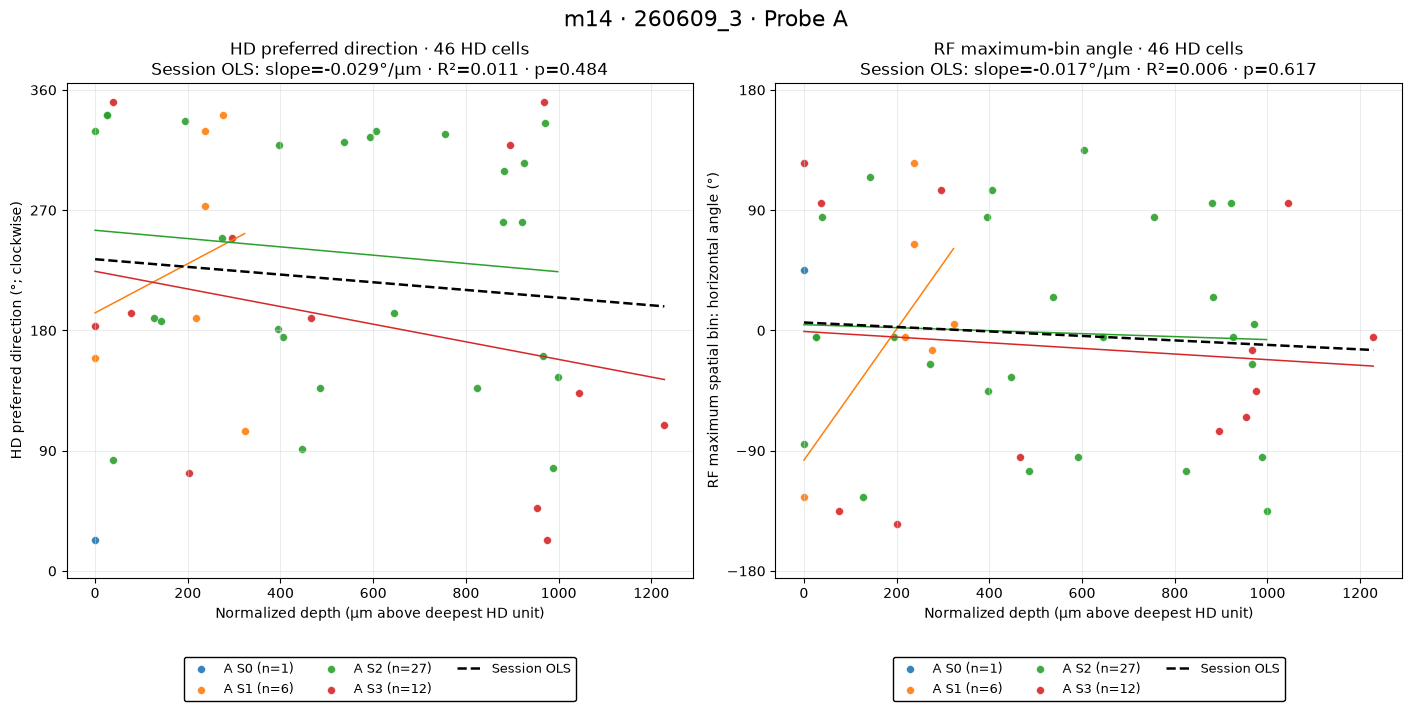

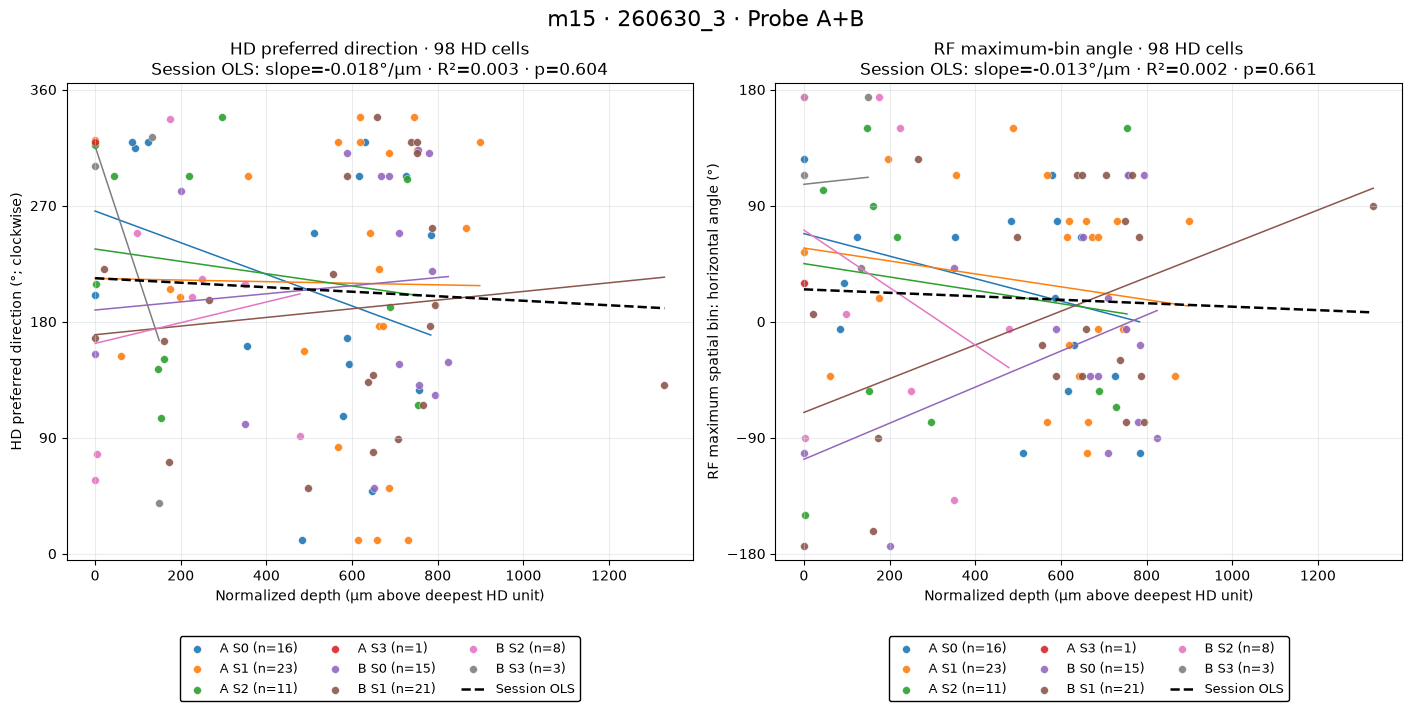

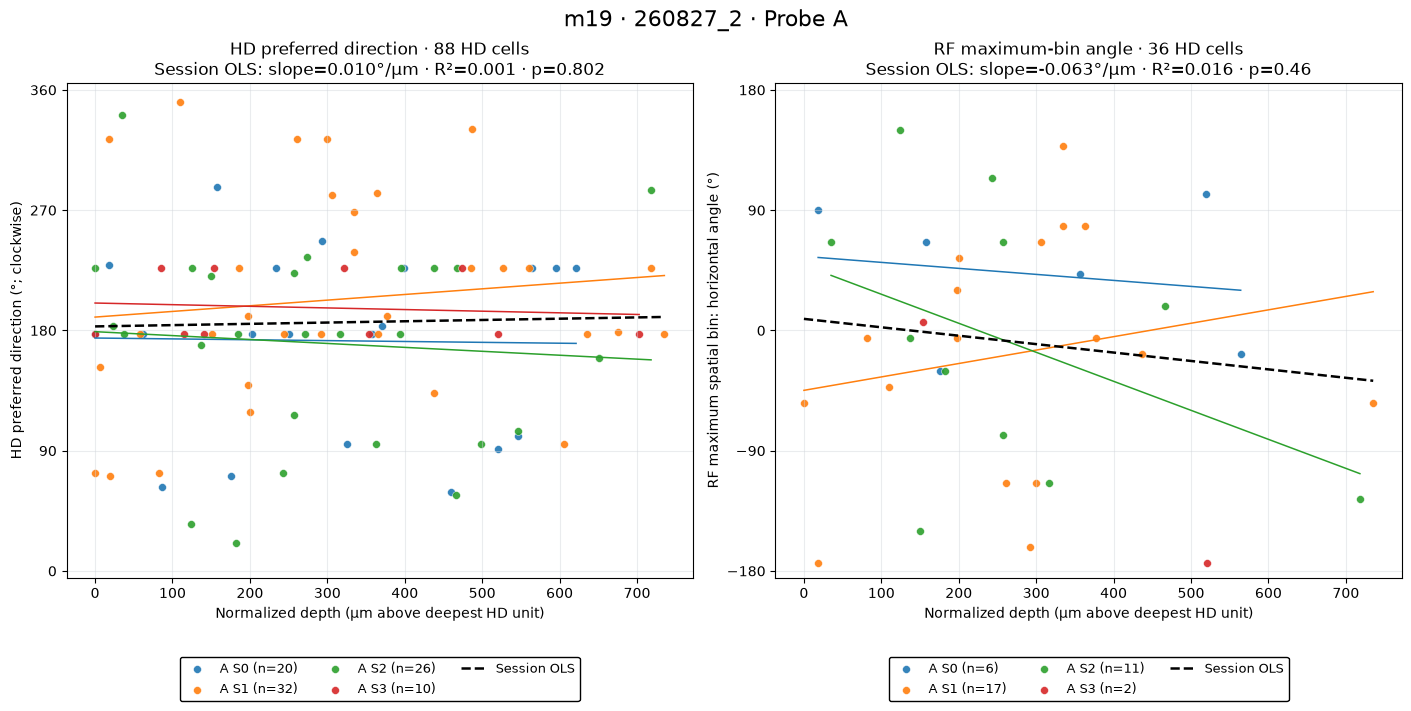

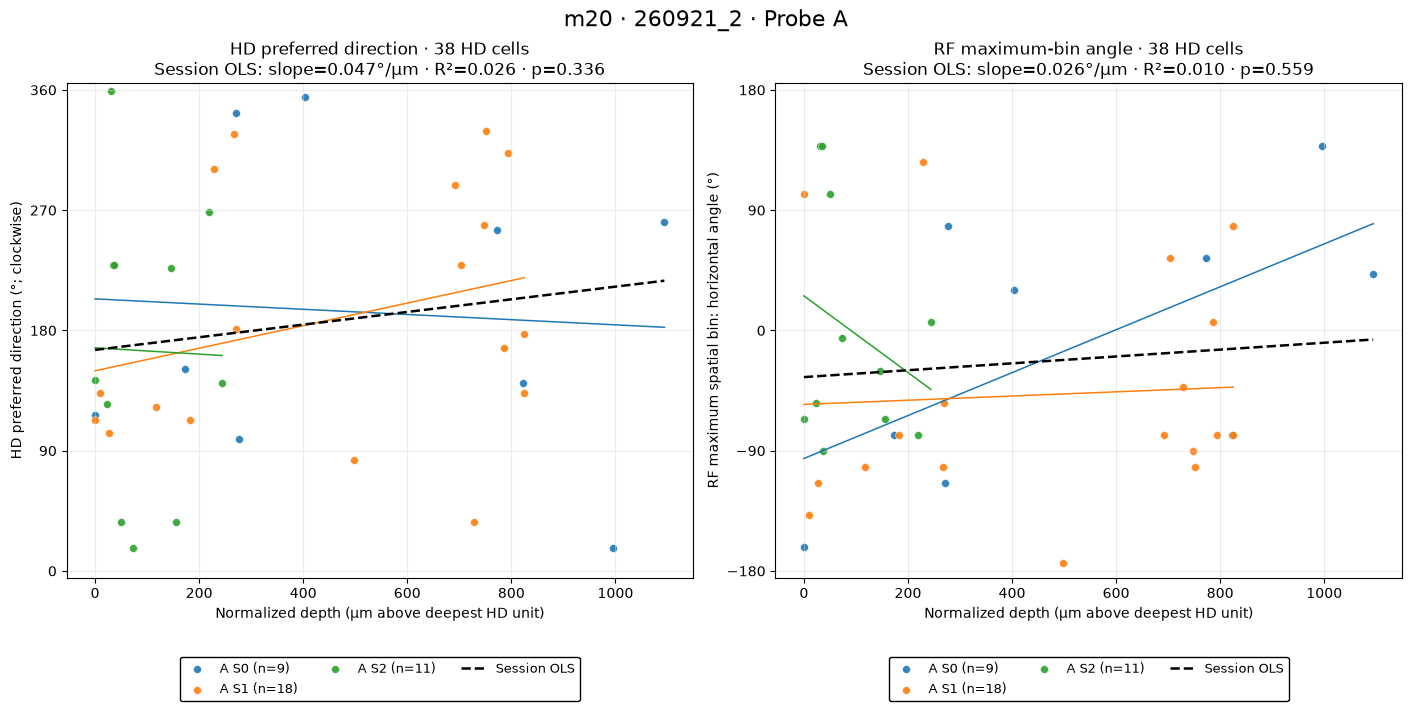

,mouse,date,rf_session,relationship,n,slope_deg_per_um,r_squared,p_value
0,m14,260609,3,HD,46,-0.02874,0.01118,0.48438
5,m14,260609,3,RF,46,-0.01676,0.00572,0.61725
10,m15,260630,3,HD,98,-0.01751,0.00281,0.60409
19,m15,260630,3,RF,98,-0.01346,0.00201,0.66112
28,m19,260827,2,HD,88,0.00963,0.00074,0.80177
33,m19,260827,2,RF,36,-0.06299,0.01614,0.46034
38,m20,260921,2,HD,38,0.04732,0.02568,0.33647
42,m20,260921,2,RF,38,0.02572,0.00959,0.55859


In [7]:
regression_tables = []
session_plot_counts = []
for (mouse, date, rf_session), session_sources in sources.groupby(
        ["mouse", "date", "rf_session"], sort=False):
    hd_session = hd_depth.loc[hd_depth.mouse.eq(mouse) & hd_depth.date.eq(date)]
    rf_session_units = rf_depth.loc[rf_depth.mouse.eq(mouse) & rf_depth.date.eq(date)]
    shank_labels = sorted(hd_session.shank_label.unique())
    colors = dict(zip(shank_labels, plt.colormaps["tab10"](np.arange(len(shank_labels))), strict=True))
    hd_fits = fit_relationship(hd_session, "hd_preferred_deg", "HD")
    rf_fits = fit_relationship(rf_session_units, "rf_max_angle_deg", "RF")
    regression_tables.append(pd.concat([hd_fits, rf_fits], ignore_index=True).assign(
        mouse=mouse, date=date, rf_session=int(rf_session)))

    fig, axes = plt.subplots(1, 2, figsize=(14, 7), sharex=True, layout="constrained")
    probes = "+".join(session_sources.probe)
    fig.suptitle(f"{mouse} · {date}_{rf_session} · Probe {probes}", fontsize=16)
    plot_depth(axes[0], hd_session, "hd_preferred_deg", hd_fits, colors,
               f"HD preferred direction · {len(hd_session)} HD cells",
               "HD preferred direction (°; clockwise)", (-5, 365))
    plot_depth(axes[1], rf_session_units, "rf_max_angle_deg", rf_fits, colors,
               f"RF maximum-bin angle · {len(rf_session_units)} HD cells",
               "RF maximum spatial bin: horizontal angle (°)", (-185, 185))
    axes[0].set_yticks([0, 90, 180, 270, 360])
    axes[1].set_yticks([-180, -90, 0, 90, 180])
    figure_file = output_dir / f"session_{mouse}_{date}_{rf_session}.png"
    fig.savefig(figure_file, dpi=180, facecolor="white", transparent=False)
    session_plot_counts.append(dict(mouse=mouse, date=date, rf_session=int(rf_session),
                                    hd_cells=len(hd_session), rf_cells=len(rf_session_units),
                                    hd_shanks=len(shank_labels), rf_shanks=rf_session_units.shank_label.nunique(),
                                    panels=len(fig.axes), figure=str(figure_file)))
    plt.show()
regressions = pd.concat(regression_tables, ignore_index=True)
regressions.to_csv(output_dir / "linear_regressions.csv", index=False)
display(regressions.loc[regressions.shank.eq("pooled"),
                       ["mouse", "date", "rf_session", "relationship", "n",
                        "slope_deg_per_um", "r_squared", "p_value"]].round(5))


## Verification and saved outputs

The checks below verify that HD units were joined once, each nonempty shank has a zero-depth reference, RF selection did not move those references, and all finite plotted data come from a Class 3 unit. Geometry verification covers every recorded channel on every shank, including empty shanks. Empty shanks are absent from the plots and regression tables.

Outputs: `hd_overview.png`, four `session_<mouse>_<date>_<rf_session>.png` figures (each 1×2), `sources.csv`, `depth_convention.csv`, `unit_angles_depth.csv`, `shank_summary.csv`, `linear_regressions.csv`, and `verification.json` in `output/retinotopography/`.

In [8]:
assert units.hd_class.eq(3).all()
assert len(units) == sources.hd_count.sum()
assert np.isfinite(hd_depth[["normalized_depth_um", "hd_preferred_deg"]]).all().all()
assert np.isfinite(rf_depth[["normalized_depth_um", "rf_max_angle_deg"]]).all().all()
assert set(rf_depth.shank_label) <= set(hd_depth.shank_label)
assert geometry.max_coordinate_error_um.eq(0).all()
assert len(session_plot_counts) == 4
assert all(item["panels"] == 2 for item in session_plot_counts)
assert sum(item["hd_cells"] for item in session_plot_counts) == len(hd_depth)
assert sum(item["rf_cells"] for item in session_plot_counts) == len(rf_depth)
source_hashes = {}
for source in sources.itertuples():
    for filename in [source.hd_file, source.settings_file,
                     str(Path(source.waveform_dir) / "channels.csv"),
                     str(Path(source.position_dir) / "positions.csv")]:
        source_hashes[filename] = hashlib.sha256(Path(filename).read_bytes()).hexdigest()
verification = dict(
    python_executable=sys.executable,
    hd_class=hd_class, response_window_s=response_window_s,
    require_rf_detection=require_rf_detection, hd_cells=int(len(units)),
    hd_cells_with_depth=int(len(hd_depth)), rf_cells_with_depth=int(len(rf_depth)),
    plotted_hd_shanks=int(hd_depth.shank_label.nunique()),
    plotted_rf_shanks=int(rf_depth.shank_label.nunique()),
    all_shanks_smaller_y_is_deeper=bool(geometry.deeper_is.eq("smaller_y").all()),
    max_channel_coordinate_error_um=float(geometry.max_coordinate_error_um.max()),
    session_figures=session_plot_counts, sha256=source_hashes)
(output_dir / "verification.json").write_text(json.dumps(verification, indent=2) + "\n")
display(pd.Series({k: v for k, v in verification.items() if k != "sha256"}))
display(regressions.loc[regressions.shank.eq("pooled")].round(6))


python_executable                        /home/kai/.virtualenvs/rfmapping/bin/python
hd_class                                                                           3
response_window_s                                                         (0.0, 0.2)
require_rf_detection                                                           False
hd_cells                                                                         270
hd_cells_with_depth                                                              270
rf_cells_with_depth                                                              218
plotted_hd_shanks                                                                 19
plotted_rf_shanks                                                                 19
all_shanks_smaller_y_is_deeper                                                  True
max_channel_coordinate_error_um                                                  0.0
session_figures                    [{'mouse': 'm14', 'date': '260

,relationship,shank,n,slope_deg_per_um,intercept_deg,r_squared,p_value,slope_stderr,status,mouse,date,rf_session
0,HD,pooled,46,-0.028735,233.292531,0.011177,0.484376,0.040745,fit,m14,260609,3
5,RF,pooled,46,-0.016762,5.945829,0.005724,0.617253,0.033303,fit,m14,260609,3
10,HD,pooled,98,-0.017506,213.734854,0.002811,0.604095,0.033650,fit,m15,260630,3
19,RF,pooled,98,-0.013456,25.075042,0.002010,0.661122,0.030600,fit,m15,260630,3
28,HD,pooled,88,0.009628,183.008090,0.000737,0.801768,0.038231,fit,m19,260827,2
33,RF,pooled,36,-0.062989,8.649275,0.016137,0.460343,0.084350,fit,m19,260827,2
38,HD,pooled,38,0.047319,165.436380,0.025685,0.336467,0.048573,fit,m20,260921,2
42,RF,pooled,38,0.025718,-34.923601,0.009591,0.558586,0.043558,fit,m20,260921,2
